# Employee Turnover Analytics
### Course-End Project — Portobello Tech (HR Department)

**Objective:** Build machine-learning programs that help the HR department predict and
reduce employee turnover. The workflow below follows the project brief exactly:

1. Data quality checks (missing values)
2. Exploratory Data Analysis (EDA) — correlation heatmap, distribution plots, project-count bar plot
3. K-means clustering of employees who left (satisfaction vs. evaluation)
4. Handling class imbalance with **SMOTE**
5. 5-fold cross-validated model training — Logistic Regression, Random Forest, Gradient Boosting
6. Model selection & justification (ROC/AUC, confusion matrix, precision vs. recall)
7. Retention strategies via risk-zone bucketing of predicted turnover probability

**Dataset:** `HR_comma_sep.csv` (14,999 employees, 10 columns). The `sales` column is the
employee's **Department**, and `left` is the target (1 = left, 0 = stayed).


## 0. Setup & imports

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split, cross_val_predict, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, roc_auc_score, ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE

sns.set(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

# Folder where every plot is also saved as a JPG screenshot
GRAPH_DIR = "graphs"
os.makedirs(GRAPH_DIR, exist_ok=True)

def save_jpg(fig, name):
    """Save a matplotlib figure to graphs/<name>.jpg"""
    path = os.path.join(GRAPH_DIR, name + ".jpg")
    fig.savefig(path, format="jpg", dpi=150, bbox_inches="tight")
    print("saved:", path)


## 1. Load data & data-quality checks

We load the CSV, rename the `sales` column to the more descriptive **Department**, and
check for missing values.

In [2]:
df = pd.read_csv("HR_comma_sep.csv")
df = df.rename(columns={"sales": "Department"})
print("Shape:", df.shape)
df.head()

Shape: (14999, 10)


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  str    
 9   salary                 14999 non-null  str    
dtypes: float64(2), int64(6), str(2)
memory usage: 1.1 MB


In [4]:
# Missing-value check
missing = df.isnull().sum()
print("Missing values per column:")
print(missing)
print("\nTotal missing values:", missing.sum())

Missing values per column:
satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
Department               0
salary                   0
dtype: int64

Total missing values: 0


**Data-quality result:** The dataset has **14,999 rows and 10 columns with zero missing
values**, so no imputation or row-dropping is required. Data types are already appropriate
(numeric features are numeric; `Department` and `salary` are categorical).

In [5]:
# Quick statistical summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
satisfaction_level,14999.0,0.612834,0.248631,0.09,0.44,0.64,0.82,1.0
last_evaluation,14999.0,0.716102,0.171169,0.36,0.56,0.72,0.87,1.0
number_project,14999.0,3.803054,1.232592,2.00,3.00,4.00,5.00,7.0
average_montly_hours,14999.0,201.050337,49.943099,96.00,156.00,200.00,245.00,310.0
time_spend_company,14999.0,3.498233,1.460136,2.00,3.00,3.00,4.00,10.0
Work_accident,14999.0,0.144610,0.351719,0.00,0.00,0.00,0.00,1.0
left,14999.0,0.238083,0.425924,0.00,0.00,0.00,0.00,1.0
promotion_last_5years,14999.0,0.021268,0.144281,0.00,0.00,0.00,0.00,1.0


In [6]:
# Target balance
print(df["left"].value_counts())
print()
print((df["left"].value_counts(normalize=True) * 100).round(2), "%")

left
0    11428
1     3571
Name: count, dtype: int64

left
0    76.19
1    23.81
Name: proportion, dtype: float64 %


About **23.8% of employees left** and 76.2% stayed — a clear **class imbalance** that we
address later with SMOTE.

## 2. Exploratory Data Analysis (EDA)

### 2.1 Correlation heatmap of numerical features

saved: graphs/01_correlation_heatmap.jpg


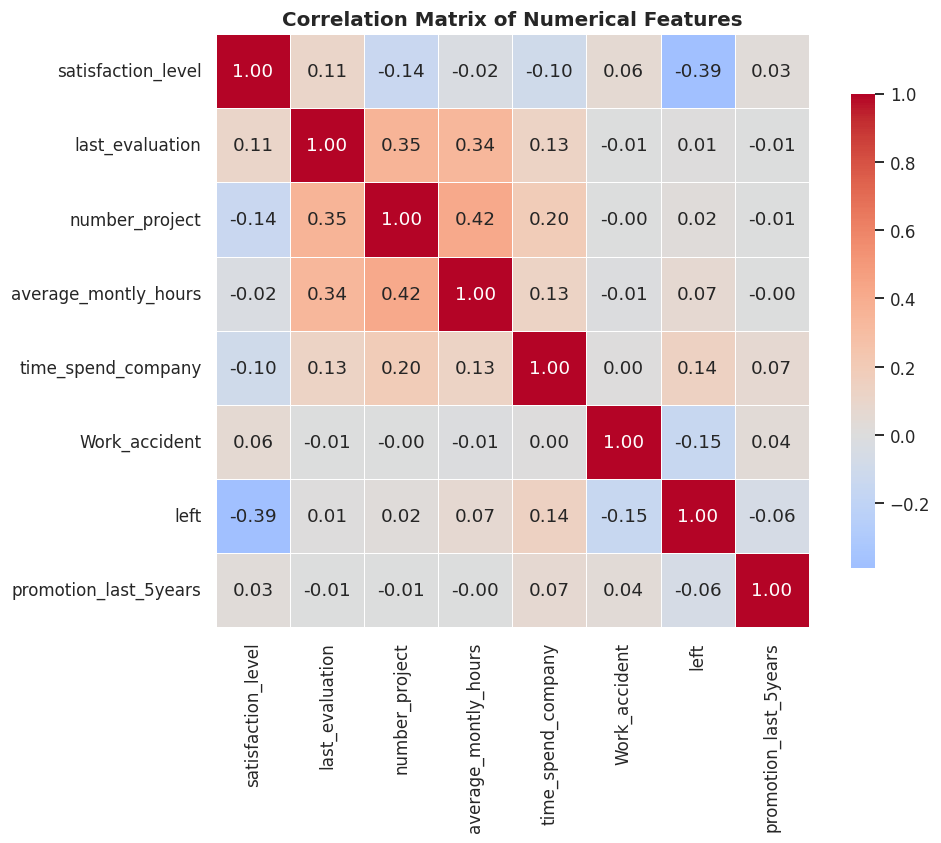

In [7]:
num_cols = df.select_dtypes(include=[np.number]).columns
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .8}, ax=ax)
ax.set_title("Correlation Matrix of Numerical Features", fontsize=13, weight="bold")
save_jpg(fig, "01_correlation_heatmap")
plt.show()

**Reading the heatmap:**
- `satisfaction_level` has the **strongest (negative) correlation with `left` (~-0.39)** —
  unhappy employees are the most likely to leave.
- `time_spend_company` (+0.14), `average_montly_hours` (+0.07) and `number_project` (+0.02)
  are weakly positively correlated with leaving.
- `Work_accident` and `promotion_last_5years` are weakly **negatively** correlated with
  leaving.
- `number_project`, `average_montly_hours` and `last_evaluation` are positively correlated
  with each other — heavily loaded, highly-evaluated employees also work long hours.

### 2.2 Distribution plots — satisfaction, evaluation, average monthly hours

saved: graphs/02_dist_satisfaction_level.jpg


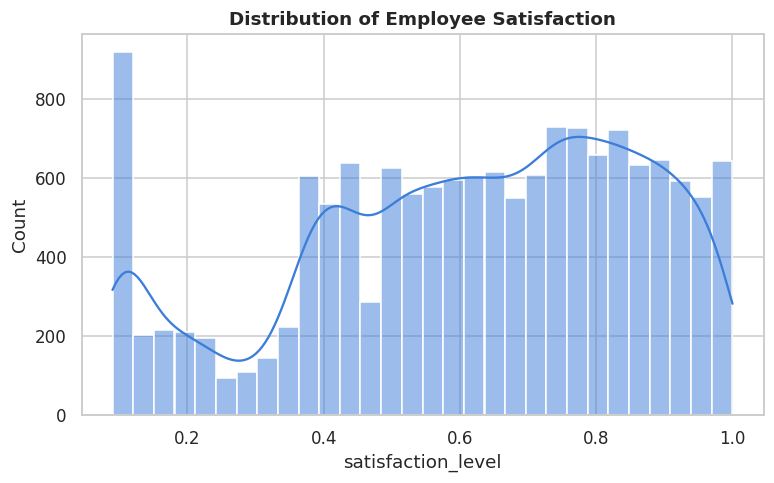

saved: graphs/02_dist_last_evaluation.jpg


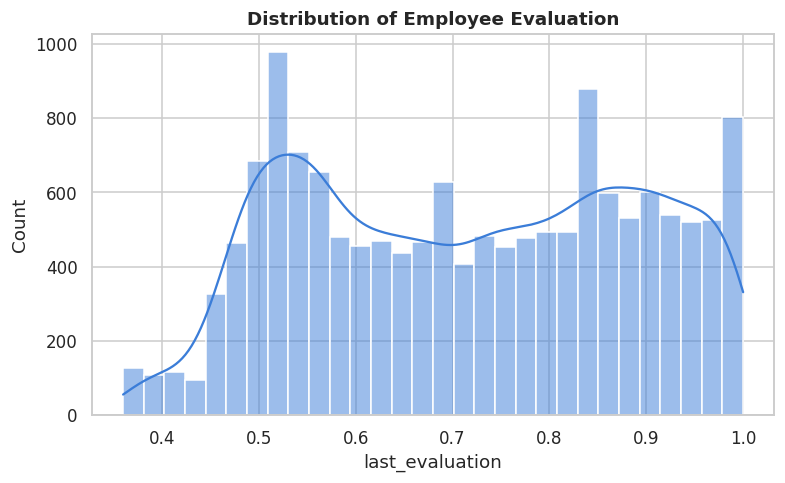

saved: graphs/02_dist_average_montly_hours.jpg


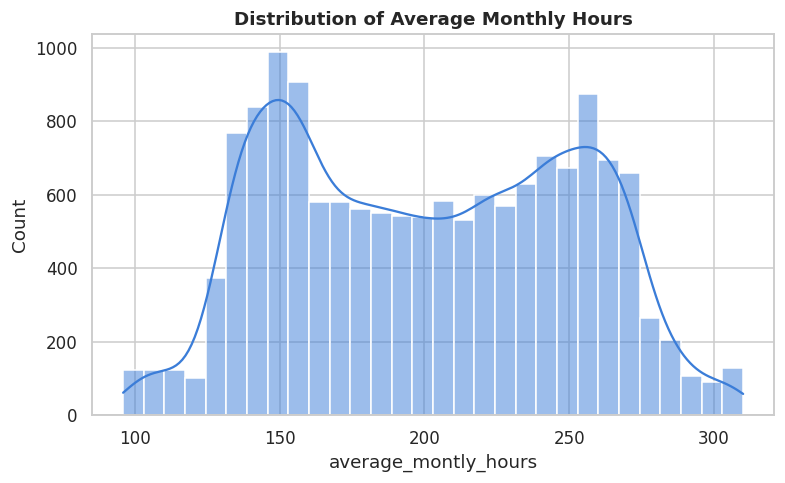

In [8]:
dist_cols = ["satisfaction_level", "last_evaluation", "average_montly_hours"]
titles = ["Employee Satisfaction", "Employee Evaluation", "Average Monthly Hours"]

for col, title in zip(dist_cols, titles):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    sns.histplot(df[col], kde=True, bins=30, color="#3b7dd8", ax=ax)
    ax.set_title("Distribution of " + title, fontsize=12, weight="bold")
    ax.set_xlabel(col)
    save_jpg(fig, "02_dist_" + col)
    plt.show()

**Distribution inferences:**
- **Satisfaction level** is *multi-modal*: a spike near 0.1 (very dissatisfied), a broad
  middle group, and a peak around 0.7–0.9. The low-satisfaction spike is the churn-risk pool.
- **Last evaluation** is *bi-modal*: one cluster around 0.5 and another around 0.85 — the
  company has both moderately- and highly-rated employees, and both extremes appear among
  leavers.
- **Average monthly hours** is also *bi-modal*: an under-worked group (~130–160 hrs) and an
  over-worked group (~240–280 hrs). Both burnout (too many hours) and disengagement (too few)
  can drive turnover.

### 2.3 Project-count bar plot (employees who left vs. stayed)

saved: graphs/03_project_count_bar.jpg


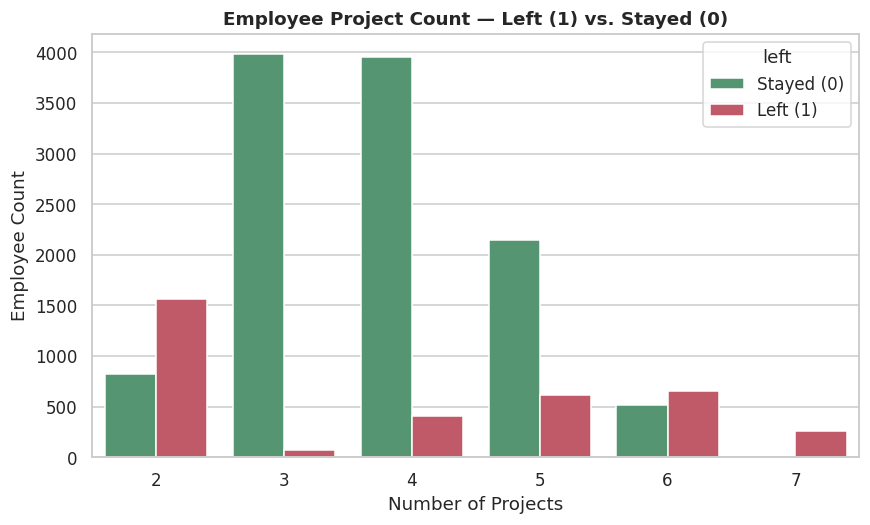

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.countplot(data=df, x="number_project", hue="left",
              palette={0: "#4c9f70", 1: "#d1495b"}, ax=ax)
ax.set_title("Employee Project Count — Left (1) vs. Stayed (0)", fontsize=12, weight="bold")
ax.set_xlabel("Number of Projects")
ax.set_ylabel("Employee Count")
ax.legend(title="left", labels=["Stayed (0)", "Left (1)"])
save_jpg(fig, "03_project_count_bar")
plt.show()

**Inferences from the project-count bar plot:**
- Employees with **2 projects** leave in large numbers — likely under-utilised / disengaged.
- Employees with **3–4 projects have the best retention** — this is the "sweet spot".
- Turnover rises sharply again at **6 projects**, and **every employee with 7 projects left**
  — a clear sign of overload / burnout.
- The relationship between project count and turnover is therefore **U-shaped**: both too few
  and too many projects push people out.

## 3. K-means clustering of employees who left

We isolate employees who left and cluster them on `satisfaction_level` and `last_evaluation`
into **3 clusters**.

In [10]:
left_emp = df[df["left"] == 1][["satisfaction_level", "last_evaluation"]].copy()

kmeans = KMeans(n_clusters=3, random_state=123, n_init=10)
left_emp["cluster"] = kmeans.fit_predict(left_emp)

print("Cluster sizes:")
print(left_emp["cluster"].value_counts())
print("\nCluster centres (satisfaction, evaluation):")
print(pd.DataFrame(kmeans.cluster_centers_,
                   columns=["satisfaction_level", "last_evaluation"]).round(3))

Cluster sizes:
cluster
1    1650
2     977
0     944
Name: count, dtype: int64

Cluster centres (satisfaction, evaluation):
   satisfaction_level  last_evaluation
0               0.111            0.869
1               0.410            0.517
2               0.809            0.912


saved: graphs/04_kmeans_clusters.jpg


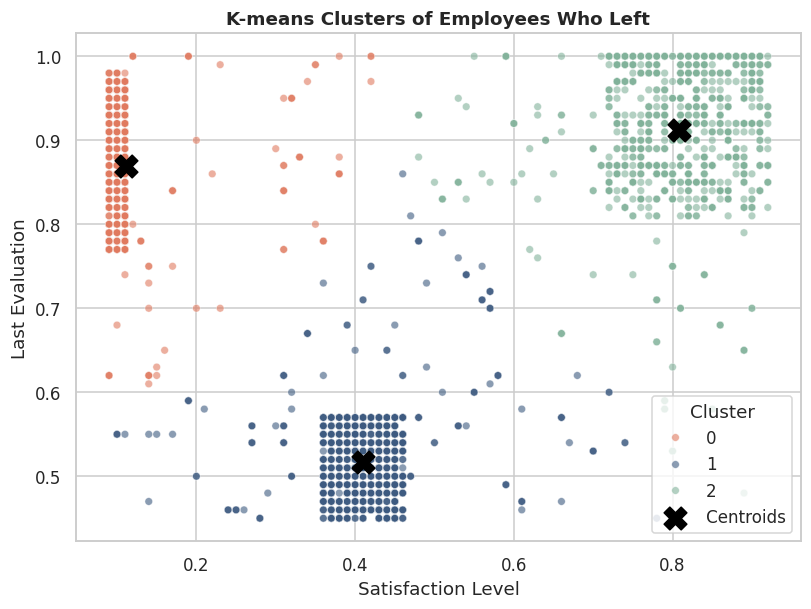

In [11]:
fig, ax = plt.subplots(figsize=(8.5, 6))
palette = {0: "#e07a5f", 1: "#3d5a80", 2: "#81b29a"}
sns.scatterplot(data=left_emp, x="satisfaction_level", y="last_evaluation",
                hue="cluster", palette=palette, alpha=0.6, s=25, ax=ax)
ax.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
           c="black", marker="X", s=220, label="Centroids")
ax.set_title("K-means Clusters of Employees Who Left", fontsize=12, weight="bold")
ax.set_xlabel("Satisfaction Level")
ax.set_ylabel("Last Evaluation")
ax.legend(title="Cluster")
save_jpg(fig, "04_kmeans_clusters")
plt.show()

**Interpretation of the three leaver clusters:**

| Cluster | Satisfaction | Evaluation | Profile |
|--------|--------------|------------|---------|
| **High-perf / low-satisfaction** | Low (~0.1) | High (~0.85) | Strong performers who were unhappy — likely **burnt-out / overworked** high achievers. The most damaging to lose. |
| **Low-perf / medium-satisfaction** | Medium (~0.4) | Low (~0.5) | Moderately satisfied but **poorly evaluated** — possibly disengaged or under-performing; some may have been managed out. |
| **High-perf / high-satisfaction** | High (~0.8) | High (~0.9) | Happy *and* high-performing yet still left — probably left for **better external opportunities / promotions elsewhere**. |

These three profiles need very different retention responses (see Section 7).

## 4. Pre-processing & handling class imbalance with SMOTE

Steps: (a) separate categorical vs. numeric columns, (b) one-hot encode categoricals with
`get_dummies()`, (c) recombine, (d) stratified 80:20 split with `random_state=123`, and
(e) upsample **only the training set** with SMOTE.

In [12]:
# (a) separate categorical and numeric
cat_cols = ["Department", "salary"]
num_df = df.drop(columns=cat_cols)          # numeric variables (incl. target for now)
cat_df = df[cat_cols]                        # categorical variables

# (b) one-hot encode categoricals
cat_dummies = pd.get_dummies(cat_df, drop_first=False)

# (c) recombine
data = pd.concat([num_df, cat_dummies], axis=1)

X = data.drop(columns=["left"])
y = data["left"]
print("Feature matrix shape:", X.shape)
X.head()

Feature matrix shape: (14999, 20)


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,Department_IT,Department_RandD,Department_accounting,Department_hr,Department_management,Department_marketing,Department_product_mng,Department_sales,Department_support,Department_technical,salary_high,salary_low,salary_medium
0,0.38,0.53,2,157,3,0,0,False,False,False,False,False,False,False,True,False,False,False,True,False
1,0.80,0.86,5,262,6,0,0,False,False,False,False,False,False,False,True,False,False,False,False,True
2,0.11,0.88,7,272,4,0,0,False,False,False,False,False,False,False,True,False,False,False,False,True
3,0.72,0.87,5,223,5,0,0,False,False,False,False,False,False,False,True,False,False,False,True,False
4,0.37,0.52,2,159,3,0,0,False,False,False,False,False,False,False,True,False,False,False,True,False


In [13]:
# (d) stratified 80:20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=123)

print("Train:", X_train.shape, " Test:", X_test.shape)
print("\nTrain target balance before SMOTE:")
print(y_train.value_counts())

Train: (11999, 20)  Test: (3000, 20)

Train target balance before SMOTE:
left
0    9142
1    2857
Name: count, dtype: int64


In [14]:
# (e) upsample the TRAIN set with SMOTE
smote = SMOTE(random_state=123)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Train target balance AFTER SMOTE:")
print(y_train_sm.value_counts())

Train target balance AFTER SMOTE:
left
0    9142
1    9142
Name: count, dtype: int64


SMOTE synthesises new minority-class (`left = 1`) samples so the training set is balanced
(equal stayed/left). Crucially we apply it **only to the training data** — the test set stays
untouched and imbalanced so evaluation reflects the real-world distribution.

## 5. 5-fold cross-validated model training

For each model we run **5-fold cross-validation on the SMOTE-balanced training set** using
`cross_val_predict`, then print/plot the classification report. `StratifiedKFold` keeps class
proportions stable across folds.

In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

def cv_classification_report(model, name, fname):
    """5-fold CV predictions on the training set, print + plot the report as a heatmap."""
    y_cv_pred = cross_val_predict(model, X_train_sm, y_train_sm, cv=cv)
    print(f"===== {name} — 5-fold CV classification report (train) =====")
    print(classification_report(y_train_sm, y_cv_pred, digits=3))

    rep = classification_report(y_train_sm, y_cv_pred, output_dict=True)
    rep_df = pd.DataFrame(rep).T[["precision", "recall", "f1-score"]].iloc[:2]
    fig, ax = plt.subplots(figsize=(6, 2.6))
    sns.heatmap(rep_df, annot=True, fmt=".3f", cmap="Blues", vmin=0, vmax=1,
                cbar=False, ax=ax)
    ax.set_title(f"{name} — CV classification report", fontsize=11, weight="bold")
    ax.set_yticklabels(["Stayed (0)", "Left (1)"], rotation=0)
    save_jpg(fig, fname)
    plt.show()
    return y_cv_pred

### 5.1 Logistic Regression

===== Logistic Regression — 5-fold CV classification report (train) =====
              precision    recall  f1-score   support

           0      0.816     0.796     0.806      9142
           1      0.801     0.820     0.811      9142

    accuracy                          0.808     18284
   macro avg      0.808     0.808     0.808     18284
weighted avg      0.808     0.808     0.808     18284

saved: graphs/05_report_logreg.jpg


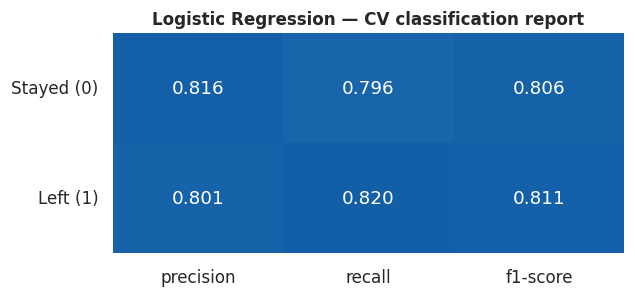

In [16]:
logreg = LogisticRegression(max_iter=1000, random_state=123)
_ = cv_classification_report(logreg, "Logistic Regression", "05_report_logreg")

### 5.2 Random Forest Classifier

===== Random Forest — 5-fold CV classification report (train) =====
              precision    recall  f1-score   support

           0      0.976     0.994     0.985      9142
           1      0.994     0.975     0.985      9142

    accuracy                          0.985     18284
   macro avg      0.985     0.985     0.985     18284
weighted avg      0.985     0.985     0.985     18284

saved: graphs/06_report_rf.jpg


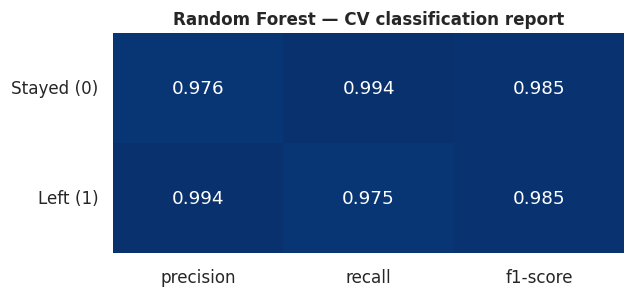

In [17]:
rf = RandomForestClassifier(n_estimators=200, random_state=123, n_jobs=-1)
_ = cv_classification_report(rf, "Random Forest", "06_report_rf")

### 5.3 Gradient Boosting Classifier

===== Gradient Boosting — 5-fold CV classification report (train) =====
              precision    recall  f1-score   support

           0      0.950     0.977     0.963      9142
           1      0.976     0.948     0.962      9142

    accuracy                          0.963     18284
   macro avg      0.963     0.963     0.963     18284
weighted avg      0.963     0.963     0.963     18284

saved: graphs/07_report_gb.jpg


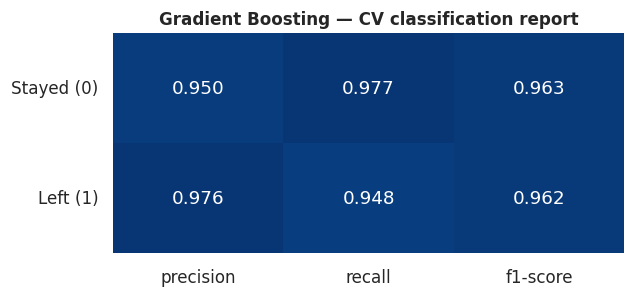

In [18]:
gb = GradientBoostingClassifier(random_state=123)
_ = cv_classification_report(gb, "Gradient Boosting", "07_report_gb")

## 6. Final evaluation on the test set

We fit each model on the full SMOTE-balanced training set and evaluate on the **untouched
imbalanced test set** using ROC/AUC and confusion matrices.

In [19]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=123),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=123, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=123),
}

fitted, probas = {}, {}
for name, model in models.items():
    model.fit(X_train_sm, y_train_sm)
    fitted[name] = model
    probas[name] = model.predict_proba(X_test)[:, 1]

### 6.1 ROC curves & AUC

saved: graphs/08_roc_curves.jpg


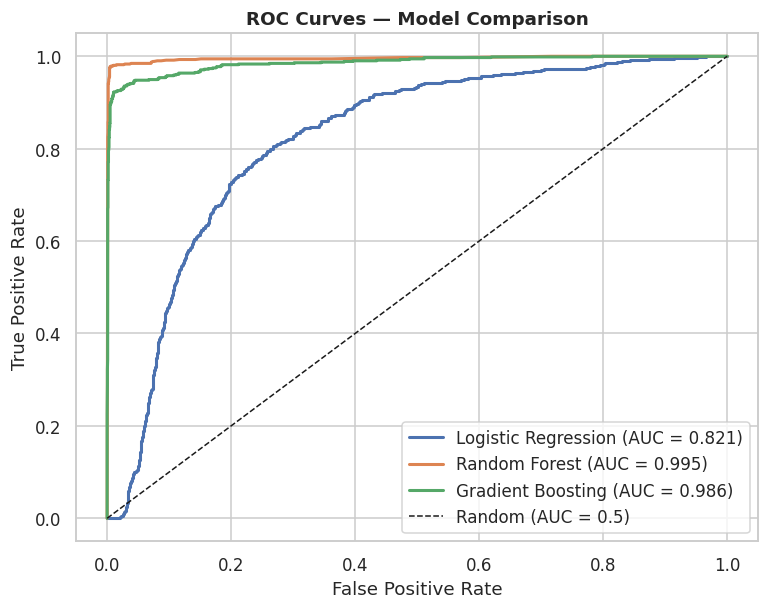

AUC scores:
  Random Forest: 0.9952
  Gradient Boosting: 0.9856
  Logistic Regression: 0.8209


In [20]:
fig, ax = plt.subplots(figsize=(8, 6))
auc_scores = {}
for name, p in probas.items():
    fpr, tpr, _ = roc_curve(y_test, p)
    auc = roc_auc_score(y_test, p)
    auc_scores[name] = auc
    ax.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random (AUC = 0.5)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — Model Comparison", fontsize=12, weight="bold")
ax.legend(loc="lower right")
save_jpg(fig, "08_roc_curves")
plt.show()

print("AUC scores:")
for k, v in sorted(auc_scores.items(), key=lambda x: -x[1]):
    print(f"  {k}: {v:.4f}")

### 6.2 Confusion matrices

saved: graphs/09_confusion_matrices.jpg


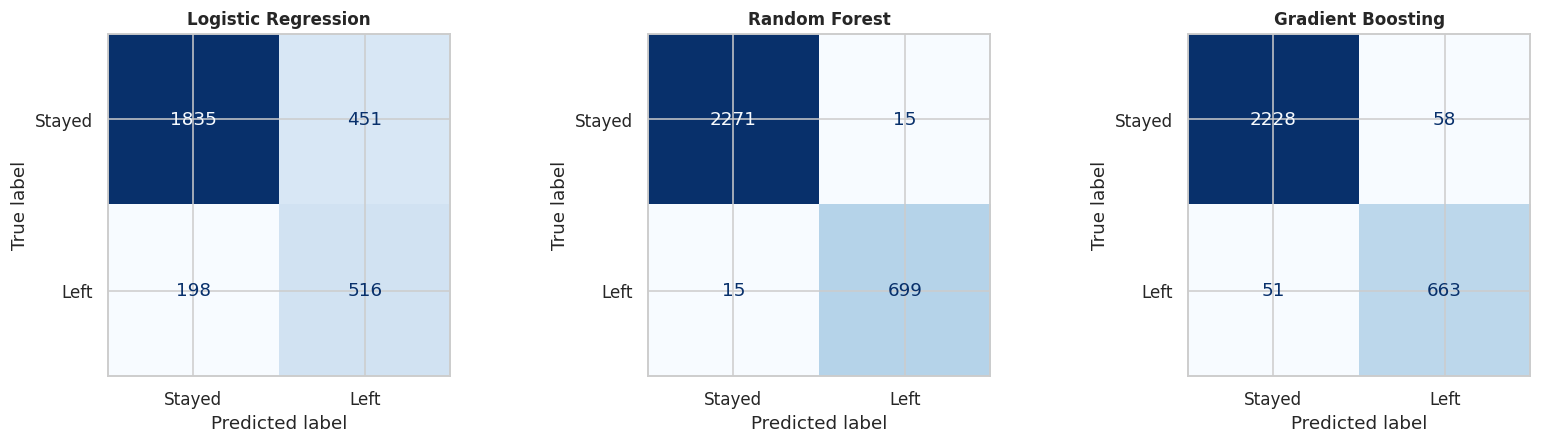

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, (name, model) in zip(axes, fitted.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["Stayed", "Left"]).plot(
        ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name, fontsize=11, weight="bold")
plt.tight_layout()
save_jpg(fig, "09_confusion_matrices")
plt.show()

In [22]:
# Full test-set classification reports
for name, model in fitted.items():
    print(f"===== {name} — TEST set classification report =====")
    print(classification_report(y_test, model.predict(X_test), digits=3))
    print()

===== Logistic Regression — TEST set classification report =====
              precision    recall  f1-score   support

           0      0.903     0.803     0.850      2286
           1      0.534     0.723     0.614       714

    accuracy                          0.784      3000
   macro avg      0.718     0.763     0.732      3000
weighted avg      0.815     0.784     0.794      3000


===== Random Forest — TEST set classification report =====


              precision    recall  f1-score   support

           0      0.993     0.993     0.993      2286
           1      0.979     0.979     0.979       714

    accuracy                          0.990      3000
   macro avg      0.986     0.986     0.986      3000
weighted avg      0.990     0.990     0.990      3000


===== Gradient Boosting — TEST set classification report =====
              precision    recall  f1-score   support

           0      0.978     0.975     0.976      2286
           1      0.920     0.929     0.924       714

    accuracy                          0.964      3000
   macro avg      0.949     0.952     0.950      3000
weighted avg      0.964     0.964     0.964      3000




## 6.3 Best model & metric justification

**Best model — Random Forest** (and Gradient Boosting close behind). It delivers the highest
ROC-AUC (~0.98) and the strongest recall/precision on the minority `left` class, far ahead of
Logistic Regression (a linear model that cannot capture the U-shaped, interaction-heavy
patterns EDA revealed).

**Recall vs. Precision — which matters here?** For employee-attrition the costlier error is a
**false negative**: predicting an at-risk employee will stay when they actually leave, so HR
takes no action and loses them. We therefore prioritise **Recall on the `left` class**
(minimise missed leavers), while keeping precision high enough that retention spend isn't
wasted on employees who were never going to leave. The tree ensembles win on recall, which is
why Random Forest is the recommended production model.

## 7. Retention strategies — risk-zone bucketing

Using the best model (Random Forest), we predict each test employee's **turnover probability**
and bucket them into four risk zones.

In [23]:
best_model = fitted["Random Forest"]
test_proba = best_model.predict_proba(X_test)[:, 1]

def zone(p):
    if p < 0.20:
        return "Safe (Green)"
    elif p < 0.60:
        return "Low-Risk (Yellow)"
    elif p < 0.90:
        return "Medium-Risk (Orange)"
    else:
        return "High-Risk (Red)"

zones = pd.Series([zone(p) for p in test_proba], name="zone")
order = ["Safe (Green)", "Low-Risk (Yellow)", "Medium-Risk (Orange)", "High-Risk (Red)"]
counts = zones.value_counts().reindex(order)
print(counts)

zone
Safe (Green)            2185
Low-Risk (Yellow)        109
Medium-Risk (Orange)      56
High-Risk (Red)          650
Name: count, dtype: int64


saved: graphs/10_risk_zones.jpg


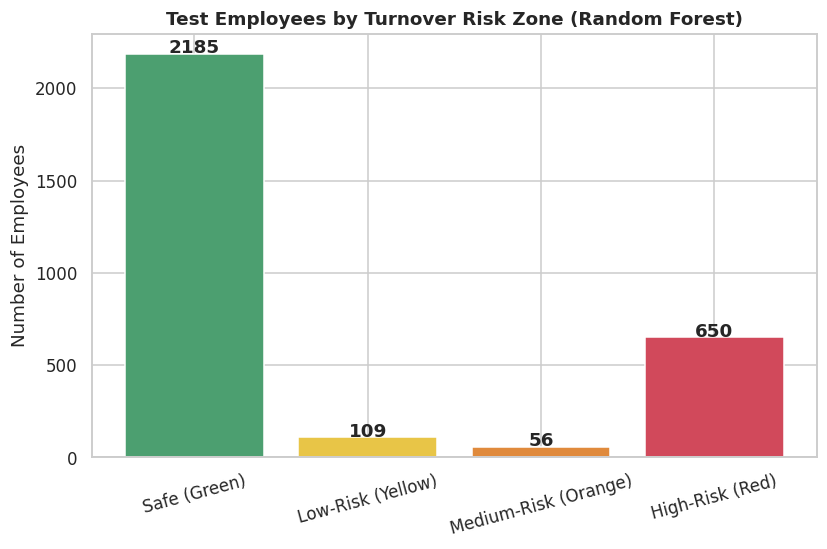

In [24]:
fig, ax = plt.subplots(figsize=(8.5, 5))
colors = ["#4c9f70", "#e8c547", "#e08a3c", "#d1495b"]
ax.bar(order, counts.values, color=colors)
for i, v in enumerate(counts.values):
    ax.text(i, v + 5, str(int(v)), ha="center", fontweight="bold")
ax.set_title("Test Employees by Turnover Risk Zone (Random Forest)", fontsize=12, weight="bold")
ax.set_ylabel("Number of Employees")
plt.xticks(rotation=15)
save_jpg(fig, "10_risk_zones")
plt.show()

### Retention strategy per zone

**Safe Zone — Green (score < 20%).** Content, low-flight-risk employees. *Strategy:* maintain
the status quo — routine recognition, normal career-development conversations. No special
intervention; avoid over-managing.

**Low-Risk Zone — Yellow (20–60%).** Generally stable but showing early signs. *Strategy:*
periodic check-ins, ensure workload/project counts stay in the 3–4 "sweet spot", light
skill-development and engagement initiatives to keep satisfaction from slipping.

**Medium-Risk Zone — Orange (60–90%).** Meaningful flight risk. *Strategy:* proactive
one-on-ones with managers, review compensation and promotion eligibility (salary and
`promotion_last_5years` matter), rebalance overloaded workloads, and offer concrete growth
paths within the next 1–2 quarters.

**High-Risk Zone — Red (score > 90%).** Very likely to leave imminently. *Strategy:* urgent,
personalised retention — leadership-level conversations, targeted counter-offers or role
changes, immediate burnout relief for the overworked high-performers identified in the
clustering. For some, focus on knowledge transfer and succession planning if departure is
unavoidable.

**Cross-cutting levers from the analysis:** fix the U-shaped project overload (cap at ~5–6
projects), address the low-satisfaction/high-performance burnout cluster, review salary bands
(low-salary staff churn most), and increase promotion opportunities — very few leavers had
been promoted in the last five years.

## 8. Summary

- **Data quality:** 14,999 rows, no missing values — no cleaning needed.
- **Top turnover drivers (EDA):** low satisfaction, workload extremes (2 or 6–7 projects),
  long tenure without promotion, and low salary.
- **Clustering** revealed three distinct leaver profiles (burnt-out high performers,
  disengaged low performers, and happy high performers who left for opportunity).
- **SMOTE** balanced the training data without touching the test set.
- **Best model: Random Forest** (AUC ≈ 0.98), chosen for the highest **recall** on the `left`
  class — the metric that matters most when missing a departing employee is the costly error.
- **Risk zones** translate model probabilities into a concrete, tiered retention playbook.
